In [1]:
import sys
sys.path.insert(1, '/work1/okoro/type3detectosra/') # 
import matplotlib.dates as mdates
import datetime
import matplotlib.pyplot as plt
import numpy as np
import astropy.io.fits as fits
import scipy
from astropy.time import Time
import matplotlib as mpl
import os

In [2]:
#fname ="/net/lyot/scratch3/vocks/OSRA/1998/CD_232/980820_232.roh"
#fname ="/net/lyot/scratch3/vocks/OSRA/2003/CD_301/031028_301.roh"
fname ="/net/lyot/scratch3/vocks/OSRA/2003/CD_300/031027_300.roh" 

f1= 800.0 -np.array(range(256))*400./256.
f2 = 400.0 -np.array(range(256))*200./255.
f3 = 170.0 -np.array(range(256))*70./256.
f4 = 100.0 -np.array(range(256))*60./255.
f_fits = np.concatenate ((f1,f2,f3,f4))

In [3]:
    #get file size
file_stats = os.stat(fname)
print(file_stats) #prints out all parameters
print(file_stats.st_size) #prints only the file size
print(file_stats.st_size / 1040) # compare with (a=fstat(lun) & a1=a.size/1040 & na=long(a1)) from read_pots_roh.pro idl
a1 = int( file_stats.st_size / 1040 + 0.5) #reason for adding  0.5 is for rounding up errors. recognise and interpret a1 as  floating

os.stat_result(st_mode=33188, st_ino=335151491, st_dev=92, st_nlink=1, st_uid=2048, st_gid=204, st_size=618390240, st_atime=1777394022, st_mtime=1067863678, st_ctime=1629387667)
618390240
594606.0


In [4]:
    #create numpy array for time Time(datetime.datetime(year, month, day, hour, minute, second))
dummy_start = np.datetime64('2025-02-01T15:23:15.00')
t_fits = dummy_start + np.linspace(0, 1, a1).astype('timedelta64[D]')

dyspec=np.zeros((a1,1024), dtype=np.ubyte)
file = open(fname, "rb")
for i in range(a1):
    data_chunk = file.read(1040)
    np_data_chunk = np.frombuffer(data_chunk, dtype=np.uint8)
    year = int(np_data_chunk[0] / 16) * 10 + (np_data_chunk[0] & 15)
    if year > 50:
        year = year + 1900
    else:
        year = year + 2000

    # Extract time information
    month = int(np_data_chunk[1] / 16) * 10 + (np_data_chunk[1] & 15)
    day = int(np_data_chunk[2] / 16) * 10 + (np_data_chunk[2] & 15)
    hour = int(np_data_chunk[3] / 16) * 10 + (np_data_chunk[3] & 15)
    minute = int(np_data_chunk[4] / 16) * 10 + (np_data_chunk[4] & 15)
    second = int(np_data_chunk[5] / 16) * 10 + (np_data_chunk[5] & 15)
    microsecond = 100000 * np_data_chunk[6]

    t_fits[i] = datetime.datetime(year, month, day, hour, minute, second, microsecond)
    dyspec[i, :] = np_data_chunk[16:]  # Insert frequency information

# Close the file AFTER the loop finishes
file.close()

In [5]:
# Normalize the data
dyspec_norm=np.zeros((a1,1024), dtype=np.float32)
for j in range(1024):
    col = dyspec[:, j]
    Imax = np.amax(col)
    Imin = np.amin(col)
    
    # Check for constant column
    if Imax == Imin:
        dyspec_norm[:, j] = 127  # Set to middle value instead of normalizing
    else:
        dyspec_norm[:, j] = (col - Imin) / (Imax - Imin) * 255

In [6]:
 # Select a portion of the spectrum for visualization
# Convert to uint8 after normalization (safer)
dyspec_norm = dyspec_norm.astype(np.uint8)
dyspec_norm = dyspec_norm.T 

In [7]:
# Prepare frequency array
Frequency = f_fits[0:1024]

# Convert to matplotlib dates
t_plot = mdates.date2num(t_fits)

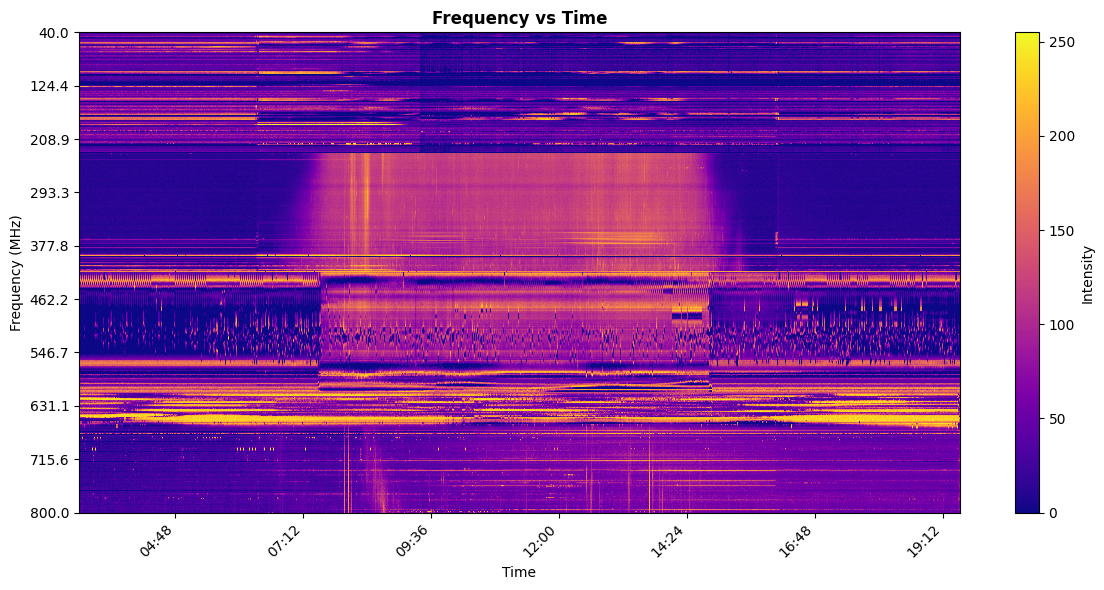

In [8]:
# Create figure and plot
fig,ax = plt.subplots(figsize=(12, 6))

im = plt.imshow(
    dyspec_norm,
    aspect='auto',
    cmap='plasma',
    extent=[t_plot[0], t_plot[-1], Frequency[0], Frequency[-1]],
    interpolation='none',  # Faster rendering
     rasterized=True  # Convert to raster for PDF export
)

# Configure axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')     # Rotate labels WITHOUT errors

# Add labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Frequency (MHz)')
ax.set_title('Frequency vs Time', fontweight="bold")
plt.colorbar(im, ax=ax, label='Intensity')

# Set frequency ticks
ax.set_yticks(np.linspace(Frequency[0], Frequency[-1], 10))

plt.tight_layout()  # Optional: Improve spacing
plt.show()